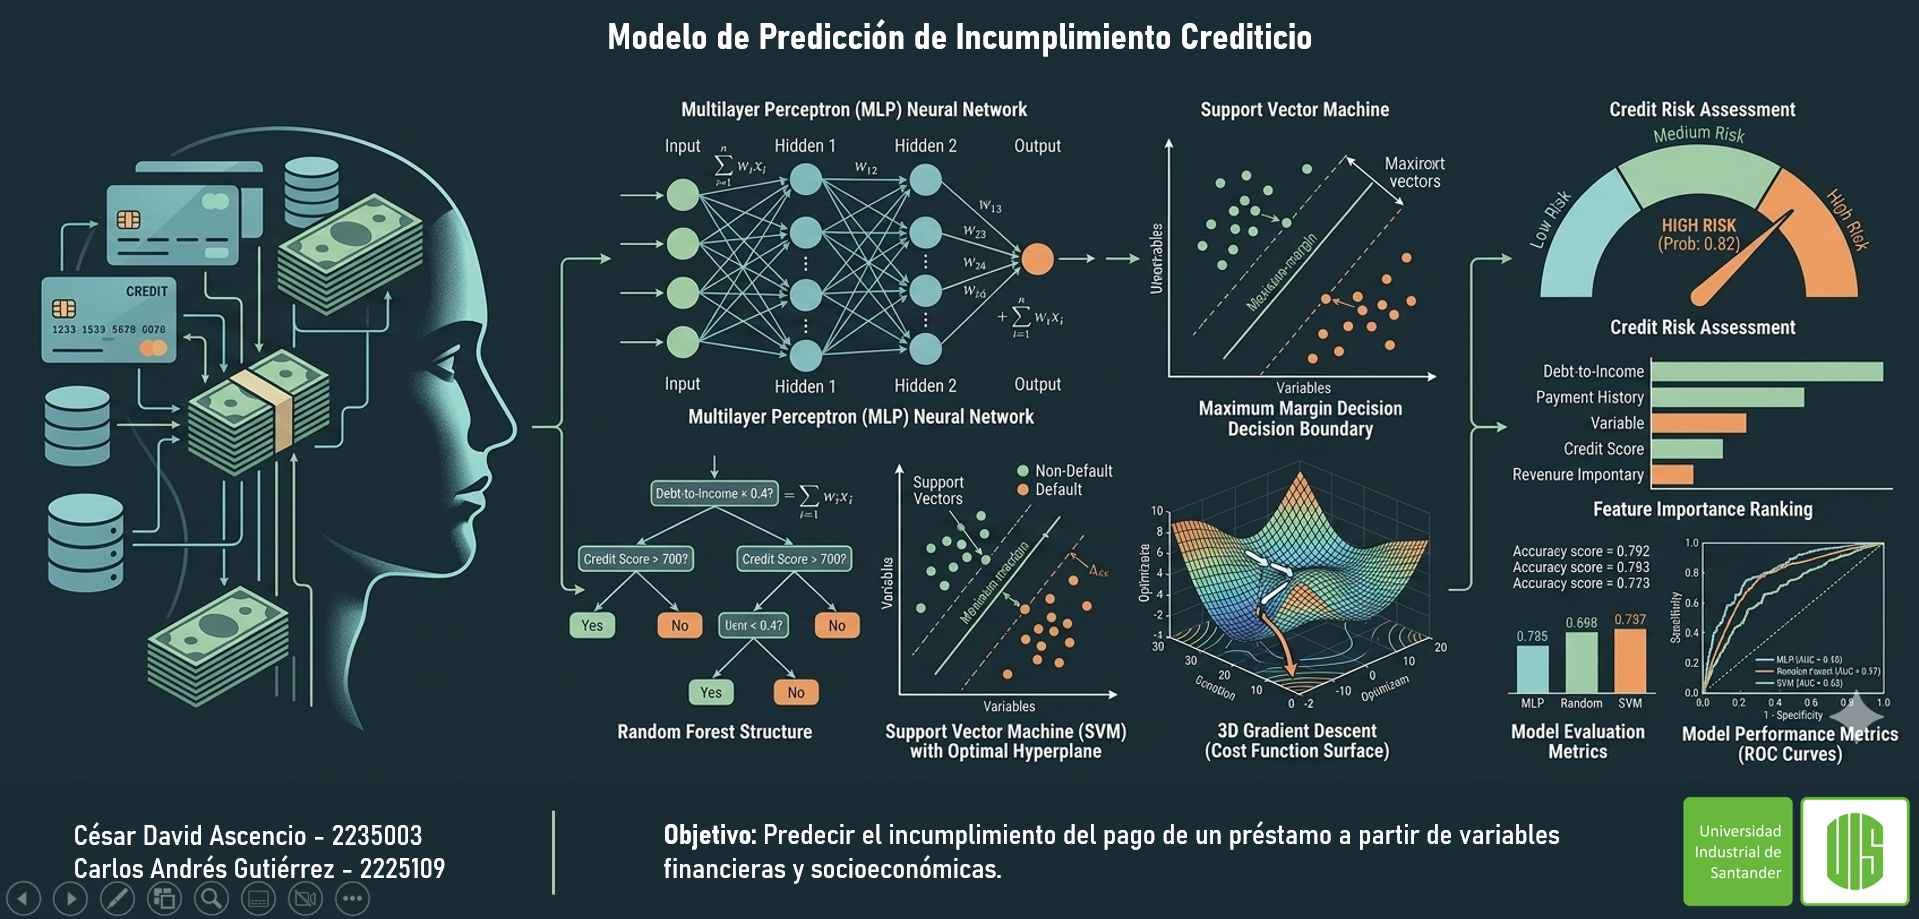

Buscamos predecir si una persona va a incumplir el pago de un préstamo usando técnicas de Machine Learning. A partir de variables financieras, se entrenaron y compararon modelos de clasificación para determinar cuál predice mejor el riesgo de incumplimiento de un solicitante de crédito.

**Dataset:** [Credit Risk Dataset — Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)  


##**Librerías**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## **1. Cargar el Dataset**

In [ ]:
#Paso 1: Conexion con drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Paso 2: Cargamos el CSV
df = pd.read_csv('/content/drive/MyDrive/IA I - 2026-1/Dataset_Proyecto/credit_risk_dataset.csv')
print(f'==== Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

==== Dataset cargado: 32,581 filas × 12 columnas


#**Primera Pre-entrega**

---
## 1.a. Exploración General

### Verificación: mínimo 300 filas y 10 columnas

In [ ]:
filas, columnas = df.shape
print(f'Shape: {filas:,} filas × {columnas} columnas')
print('Filas >= 300:   ', filas >= 300)
print('Columnas >= 10: ', columnas >= 10)

Shape: 32,581 filas × 12 columnas
Filas >= 300:    True
Columnas >= 10:  True


### df.head()

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### df.describe()

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### df.columns

In [ ]:
print(df.columns.tolist())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


### df.info()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### df.shape

In [ ]:
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

Filas:    32,581
Columnas: 12


### Valores nulos por columna

In [ ]:
nulos = df.isnull().sum()
#print(nulos)
pct   = (nulos / len(df) * 100).round(2)
#print(pct)
resumen = pd.DataFrame({'Valores Nulos': nulos, 'Porcentaje (%)': pct})
display(resumen[resumen['Valores Nulos'] > 0])

,Valores Nulos,Porcentaje (%)
person_emp_length,895,2.75
loan_int_rate,3116,9.56


### IQR — Detección de Outliers
- **Outlier inferior:** x < Q1 − 1.5 × IQR  
- **Outlier superior:** x > Q3 + 1.5 × IQR

In [ ]:
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
if 'loan_status' in cols_num:
    cols_num.remove('loan_status')

resultados = []
for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_inf = (df[col] < lim_inf).sum()
    n_sup = (df[col] > lim_sup).sum()
    resultados.append({
        'Columna': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Límite Inf.': round(lim_inf, 2), 'Límite Sup.': round(lim_sup, 2),
        'Outliers ↓': n_inf, 'Outliers ↑': n_sup,
        'Total': n_inf + n_sup,
        '% del total': round((n_inf + n_sup) / len(df) * 100, 2)
    })
#print(len(df))
display(pd.DataFrame(resultados))

,Columna,Q1,Q3,IQR,Límite Inf.,Límite Sup.,Outliers ↓,Outliers ↑,Total,% del total
0,person_age,23.00,30.00,7.00,12.50,40.50,0,1494,1494,4.59
1,person_income,38500.00,79200.00,40700.00,-22550.00,140250.00,0,1484,1484,4.55
2,person_emp_length,2.00,7.00,5.00,-5.50,14.50,0,853,853,2.62
3,loan_amnt,5000.00,12200.00,7200.00,-5800.00,23000.00,0,1689,1689,5.18
4,loan_int_rate,7.90,13.47,5.57,-0.46,21.83,0,6,6,0.02
5,loan_percent_income,0.09,0.23,0.14,-0.12,0.44,0,651,651,2.00
6,cb_person_cred_hist_length,3.00,8.00,5.00,-4.50,15.50,0,1142,1142,3.51


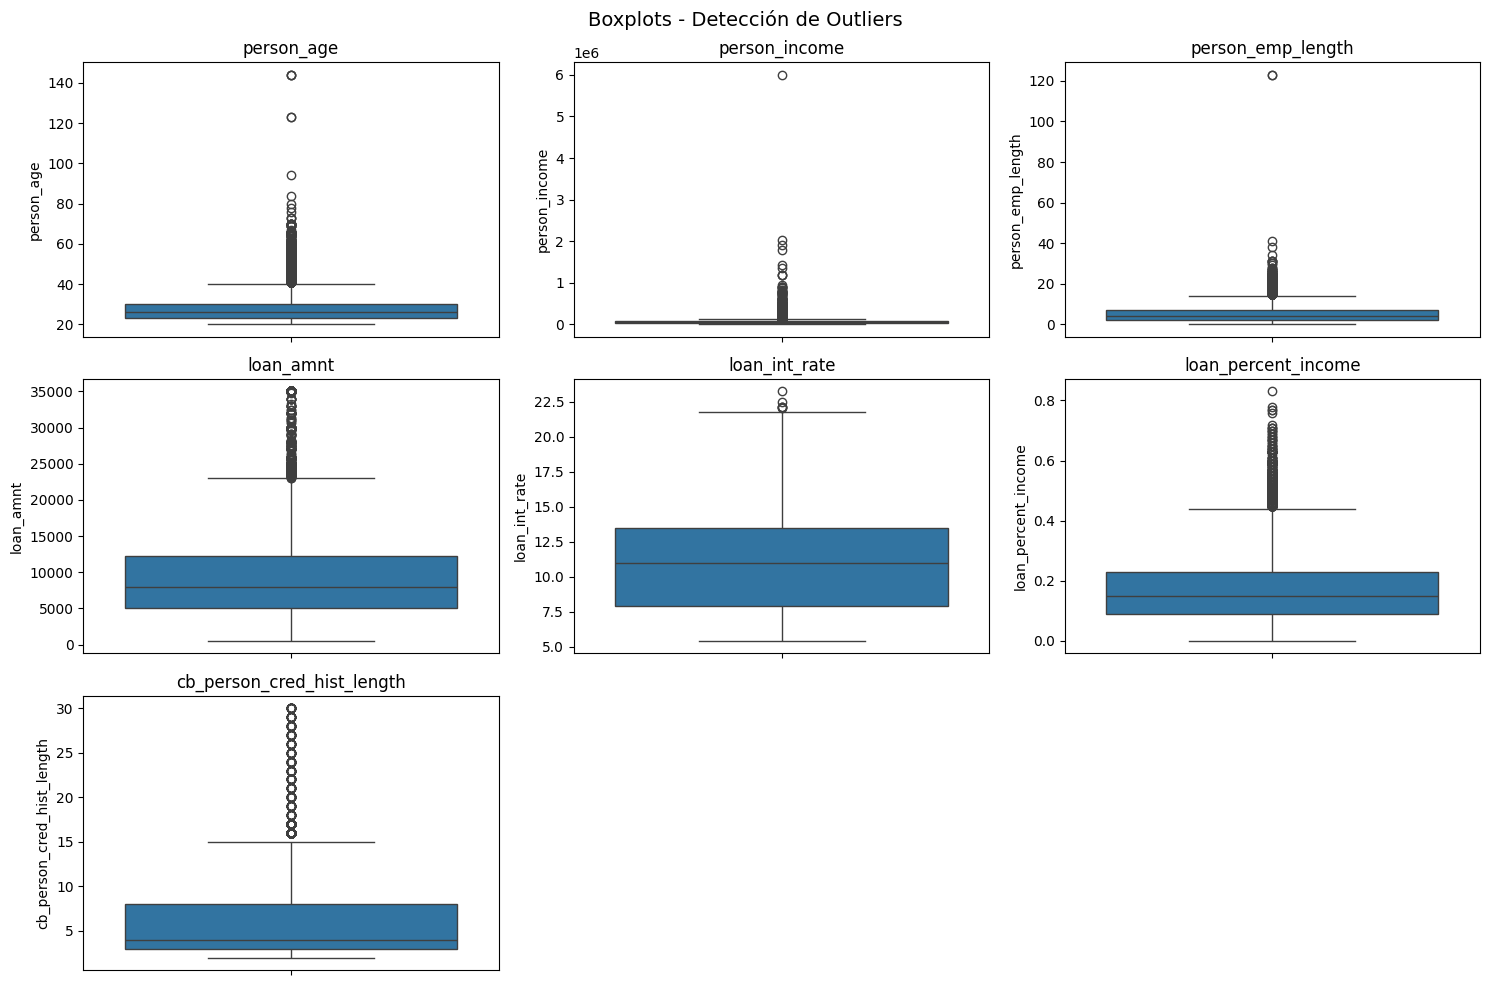

In [ ]:
# Boxplots para visualizar outliers
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_num):
  plt.subplot(3, 3, i + 1)
  sns.boxplot(y=df[col].dropna())
  plt.title(col)

plt.suptitle('Boxplots - Detección de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

---
## 1.b. Columnas Categóricas y Numéricas

In [ ]:
cols_num_all = df.select_dtypes(include=[np.number]).columns.tolist()
cols_cat     = df.select_dtypes(include=['object', 'category']).columns.tolist() # 'object' y 'category' tipos de datos en panda

print(f'Columnas NUMÉRICAS ({len(cols_num_all)}):')
for c in cols_num_all:
    print(f'   • {c}')

print(f'\nColumnas CATEGÓRICAS ({len(cols_cat)}):')
for c in cols_cat:
    print(f'   • {c}  →  {df[c].nunique()} valores únicos: {df[c].unique().tolist()}')

Columnas NUMÉRICAS (8):
   • person_age
   • person_income
   • person_emp_length
   • loan_amnt
   • loan_int_rate
   • loan_status
   • loan_percent_income
   • cb_person_cred_hist_length

Columnas CATEGÓRICAS (4):
   • person_home_ownership  →  4 valores únicos: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
   • loan_intent  →  6 valores únicos: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
   • loan_grade  →  7 valores únicos: ['D', 'B', 'C', 'A', 'E', 'F', 'G']
   • cb_person_default_on_file  →  2 valores únicos: ['Y', 'N']


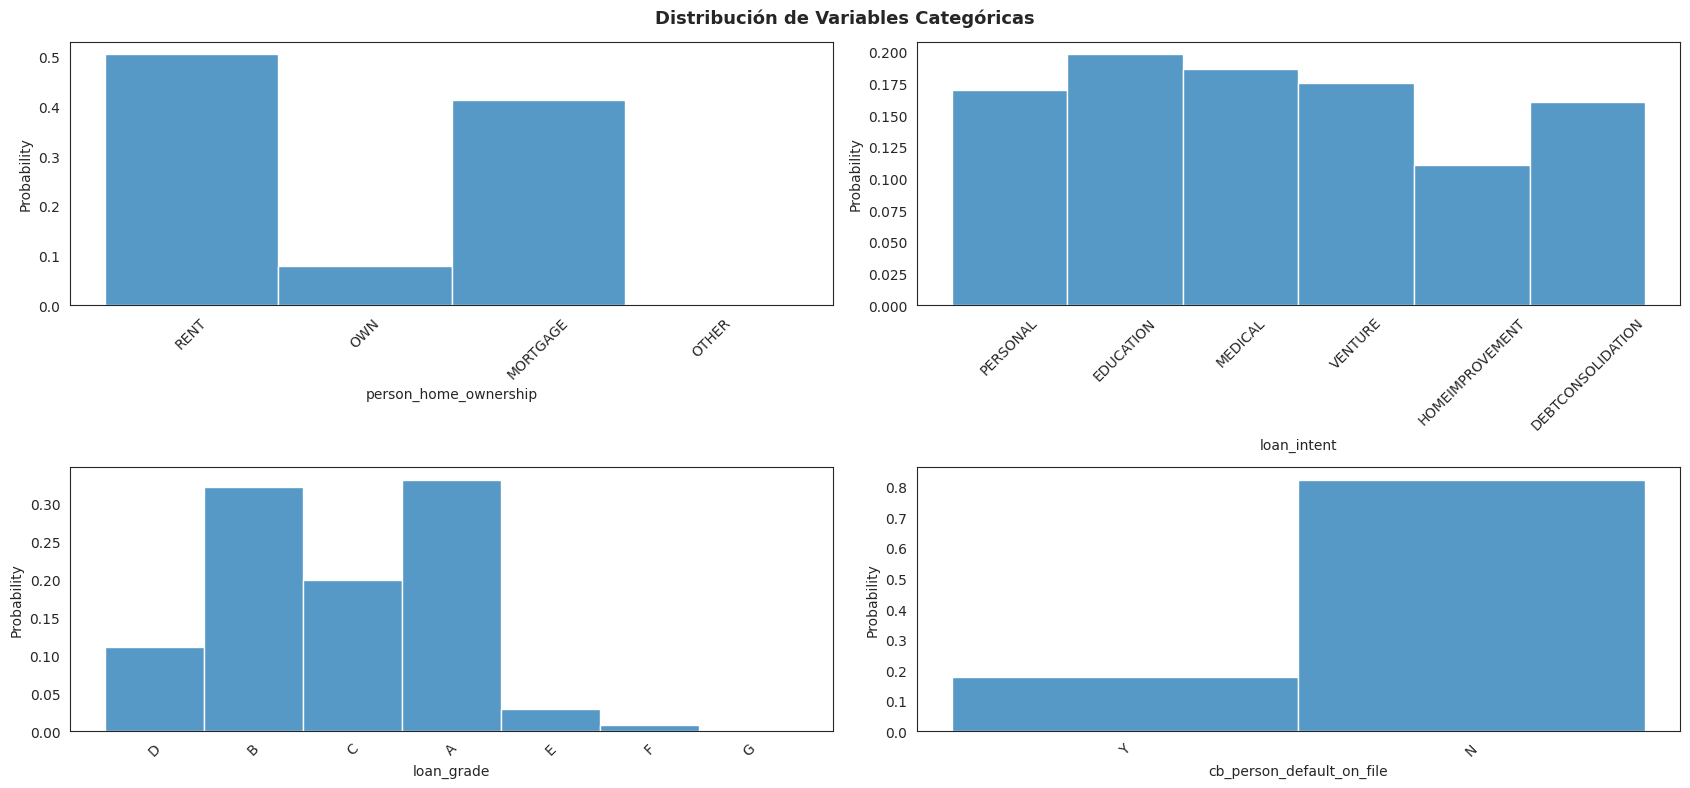

In [ ]:
# Distribución de variables categóricas
sns.set_style("white")
plt.figure(figsize=(17, 8))

for i, col in enumerate(cols_cat):
    plt.subplot(2, 2, i + 1)
    ax = sns.histplot(df[col], bins=df[col].nunique(), stat='probability')
    ax.set(xlabel=col)
    plt.xticks(rotation=45)

plt.suptitle('Distribución de Variables Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Tarea: Clasificación Binaria Supervisada

| Clase | Significado |
|-------|-------------|
| `0`   | Pago correcto |
| `1`   | Incumplimiento |

Distribución de loan_status:
  Clase 0 — Pago correcto:  25,473  (78.2%)
  Clase 1 — Incumplimiento:  7,108  (21.8%)


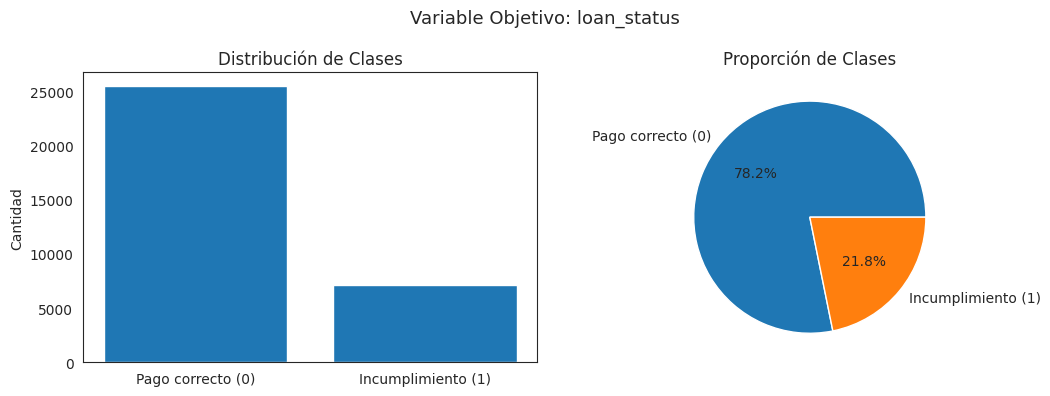


Ratio de desbalance (0/1): 3.58
Dataset desbalanceado.


In [ ]:
conteo = df['loan_status'].value_counts()
#print(conteo)
pct    = df['loan_status'].value_counts(normalize=True) * 100

print('Distribución de loan_status:')
print(f'  Clase 0 — Pago correcto:  {conteo[0]:>6,}  ({pct[0]:.1f}%)')
print(f'  Clase 1 — Incumplimiento: {conteo[1]:>6,}  ({pct[1]:.1f}%)')

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.bar(['Pago correcto (0)', 'Incumplimiento (1)'], conteo.values, width=0.8)
plt.title('Distribución de Clases')
plt.ylabel('Cantidad')

plt.subplot(1, 2, 2)
plt.pie(conteo.values,
        labels=['Pago correcto (0)', 'Incumplimiento (1)'],
        autopct='%1.1f%%')
plt.title('Proporción de Clases')

plt.suptitle('Variable Objetivo: loan_status', fontsize=13)
plt.tight_layout()
plt.show()

ratio = conteo[0] / conteo[1]
print(f'\nRatio de desbalance (0/1): {ratio:.2f}')
if ratio > 2:  # 3 por convención general, 2 más estricto
    print('Dataset desbalanceado.')
else:
    print('Dataset relativamente balanceado.')

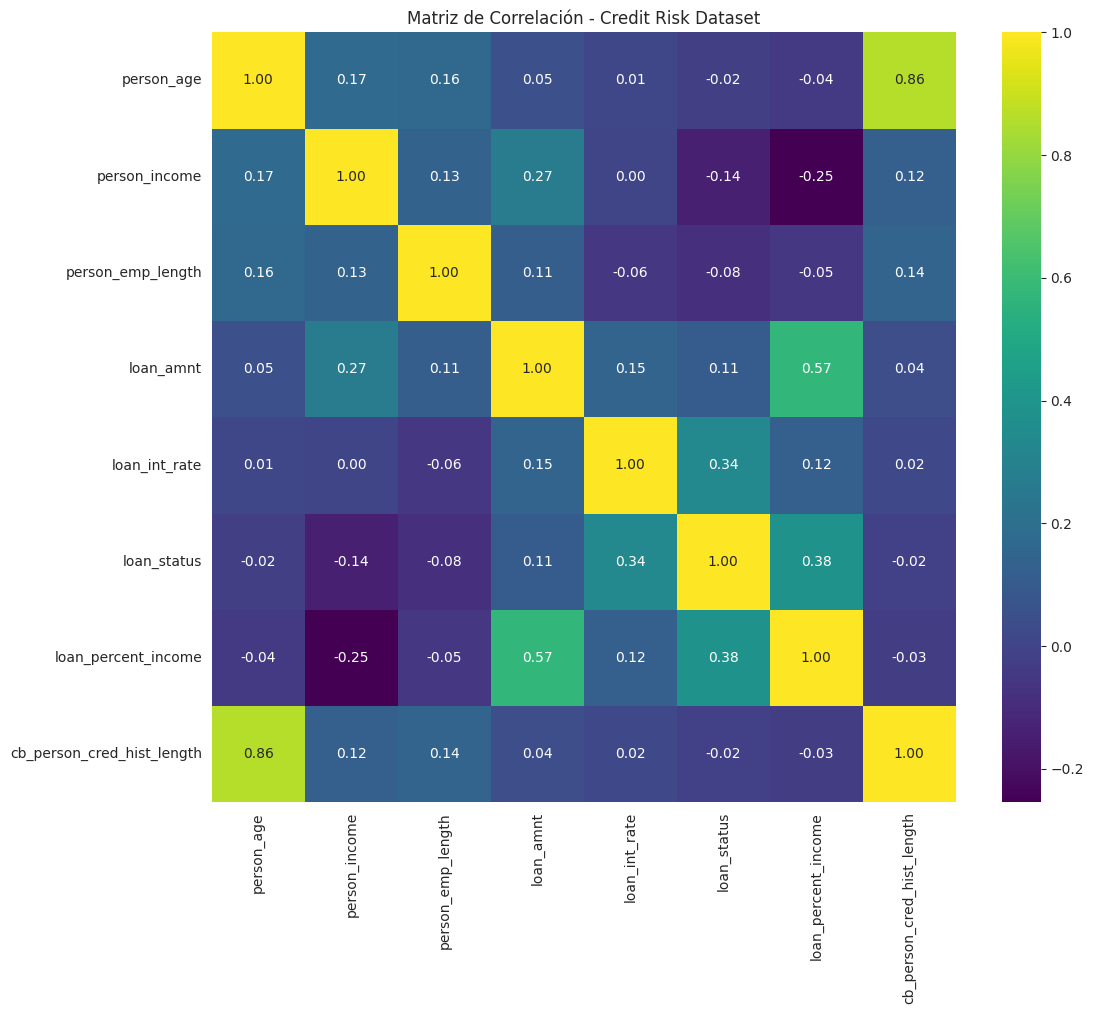

In [ ]:
df_num = df.select_dtypes(include='number')
plt.figure(figsize=(12, 10))
sns.heatmap(df_num.corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Matriz de Correlación - Credit Risk Dataset')
plt.show()

---
## Resumen Final

In [ ]:
print('=' * 50)
print('     RESUMEN — Pre-entrega 1')
print('=' * 50)
print(f'  Filas:               {df.shape[0]:>10,}')
print(f'  Columnas:            {df.shape[1]:>10}')
print(f'  Cols. numéricas:     {len(cols_num_all):>10}')
print(f'  Cols. categóricas:   {len(cols_cat):>10}')
print(f'  Valores nulos:       {df.isnull().sum().sum():>10}')
print(f'  Tarea:               Clasificación Binaria')
print(f'  Variable objetivo:   loan_status (0 / 1)')
print('=' * 50)

     RESUMEN — Pre-entrega 1
  Filas:                   32,581
  Columnas:                    12
  Cols. numéricas:              8
  Cols. categóricas:            4
  Valores nulos:             4011
  Tarea:               Clasificación Binaria
  Variable objetivo:   loan_status (0 / 1)


#**Segunda Pre-entrega**

##**1. Limpieza del dataset.**

Los valores faltantes se concentran únicamente en dos columnas:

- **`loan_int_rate:`** 3,116 nulos → **9.56%**


- **`person_emp_length:`** 895 nulos → **2.75%**

El resto del dataset está completo, lo que permite aplicar imputación puntual sin sacrificar observaciones. Eliminar las filas con nulos en **`loan_int_rate`** significaría descartar casi **1 de cada 10 registros**, una pérdida innecesaria dado que la columna tiene suficiente información para estimar un valor representativo. Para **`person_emp_length`** la proporción es menor, pero la presencia de valores extremos hace que la imputación requiera una estrategia robusta frente a outliers.

In [ ]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


###**Método de imputación de valores NaN**


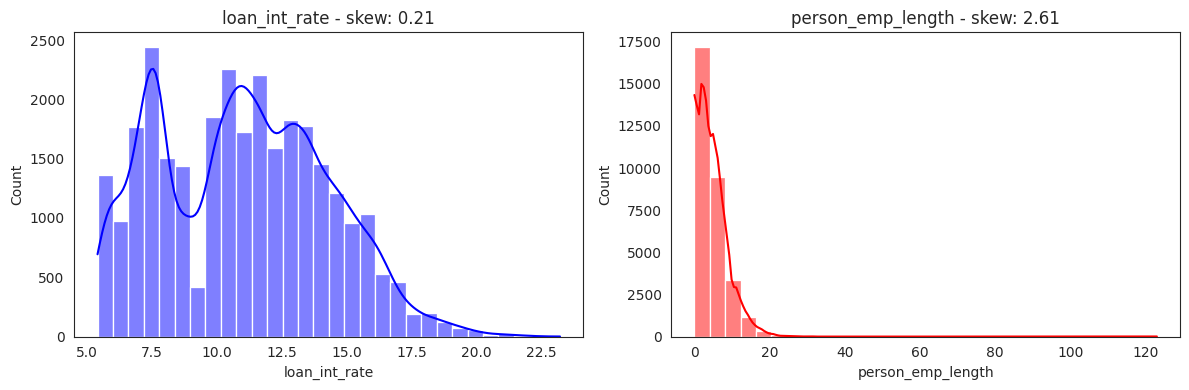

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['loan_int_rate'], kde=True, color='blue', bins=30)
plt.title('loan_int_rate - skew: 0.21')

plt.subplot(1, 2, 2)
sns.histplot(df['person_emp_length'], kde=True, color='red', bins=30)
plt.title('person_emp_length - skew: 2.61')

plt.tight_layout()
plt.show()

Los histogramas confirman visualmente por qué se eligio la mediana para imputar ambas columnas.

***`loan_int_rate`***

- Tiene un skew de **0.21**, aunque es casi simétrica, se puede ver que la distribución tiene dos picos (bimodal) y una cola hacia la derecha,
hay tasas de interés extremadamente altas que jalarían la media hacia arriba. La mediana es más segura en este caso.

***`person_emp_length`***

- Con skew de **2.61** es el caso más claro, la gran mayoría de personas **tiene entre 0 y 5 años de experiencia laboral**. Tambien hay casos extremos que llegan hasta 120 años, lo cual son errores de datos evidentes.

Si hubiéramos usado la media, esos valores absurdos habrían inflado el valor de imputación, rellenando los NaN con un número que no representa a la mayoría de los registros. La mediana ignora esos extremos y refleja el comportamiento real de la columna. Dado que **`person_emp_length`** es un indicador de estabilidad laboral — factor relevante para evaluar la capacidad de pago — una imputación correcta en esta columna tiene impacto directo en la calidad de las predicciones del modelo.

#### **Implementación.**


In [ ]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print(df.isnull().sum())
# df.columns

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


Tras aplicar la **imputación con mediana**, el dataset queda sin valores faltantes en ninguna de sus 12 columnas, confirmando que la limpieza fue exitosa.

##**2. Particionado 80/20**

**Identificación**

In [ ]:
cols_cat = df.select_dtypes(include=['object', 'category']).columns.tolist() # 'object' y 'category' tipos de datos en panda

print(f'\nColumnas CATEGÓRICAS ({len(cols_cat)}):')
for c in cols_cat:
    print(f'   • {c}  →  {df[c].nunique()} valores únicos: {df[c].unique().tolist()}')


Columnas CATEGÓRICAS (4):
   • person_home_ownership  →  4 valores únicos: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
   • loan_intent  →  6 valores únicos: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
   • loan_grade  →  7 valores únicos: ['D', 'B', 'C', 'A', 'E', 'F', 'G']
   • cb_person_default_on_file  →  2 valores únicos: ['Y', 'N']


###**Implementación**.

Las 4 columnas categóricas se codificaron numéricamente con **`pd.factorize()`** para que los modelos puedan procesarlas. La variable objetivo **`loan_status`** se separó como vector y, y el resto de columnas conforman la matriz de features X.

In [ ]:
from sklearn.model_selection import train_test_split
np.random.seed(21)

for col in ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']:
  df[col], _ = pd.factorize(df[col])

y = df['loan_status']
X = df.drop(columns=['loan_status'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=21)

Los valores faltantes no están distribuidos en todo el dataset, sino concentrados únicamente en **`loan_int_rate`** y **`person_emp_length`**. Esto permite aplicar imputación sin perder una cantidad importante de registros.

##**3. Métodos de Estimación (ML)**



#### **Decision Tree `DT`**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
np.random.seed(21)

profundidades = [2, 5, 10, 15, 20, 30, 50, 100]
accuracies = []

for i in profundidades:
  est1 = DecisionTreeClassifier(max_depth=i, random_state=21)
  est1.fit(X_train, y_train)
  metrica1 = accuracy_score(y_test, est1.predict(X_test))
  accuracies.append(metrica1)

mejor_depth = profundidades[accuracies.index(max(accuracies))]
print(f'\nMejor max_depth: {mejor_depth} → accuracy: {max(accuracies):.4f}')


Mejor max_depth: 10 → accuracy: 0.9254


El modelo alcanzó su mejor accuracy con **`max_depth=10`**, obteniendo un **92.54%** de aciertos sobre el conjunto de test. Esto significa que **de cada 100 personas, el modelo clasifica correctamente si van a incumplir o no en aproximadamente 93 casos**.

El hecho de que el mejor resultado se dé con profundidad 10 y no con valores más altos como 50 o 100 indica que el modelo **no necesita hacerse muy complejo para aprender bien los patrones del dataset**, con 10 niveles de preguntas ya captura suficiente información sobre variables como la tasa de interés, el ingreso y el historial crediticio para hacer una buena predicción.

#### **Random Forest** `RF`

In [ ]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(21)

estimators = [60, 65, 70, 75, 80, 90, 100]
accuracies = []

for i in estimators:
  est2 = RandomForestClassifier(n_estimators=i, random_state=21)
  est2.fit(X_train, y_train)
  metrica2 = accuracy_score(y_test, est2.predict(X_test))
  accuracies.append(metrica2)

mejor_est = estimators[accuracies.index(max(accuracies))]
print(f'\nMejor n_stimators: {mejor_est} → accuracy: {max(accuracies):.4f}')


Mejor n_stimators: 70 → accuracy: 0.9285


Con un **92.85%** de accuracy, el modelo clasifica correctamente a casi 93 de cada 100 personas en cuanto a si van a incumplir o no su préstamo. Esto significa que con **70 árboles el modelo tiene suficiente información para tomar buenas decisiones crediticias**, lo cual en un contexto real le permitiría a un banco reducir significativamente el riesgo de prestarle dinero a alguien que no va a pagar.



#### **Support Virtual Machine `SVM`**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_trainS = scaler.fit_transform(X_train)
X_testS = scaler.transform(X_test)

In [ ]:
def est_SVC(df, kernel, iter):
  from sklearn.svm import SVC
  from sklearn.metrics import accuracy_score
  import matplotlib.pyplot as plt
  np.random.seed(21)

  accuracies = []
  for i in iter:
      estSVC = SVC(kernel=kernel, random_state=21, max_iter=i)
      estSVC.fit(X_trainS, y_train)
      mSVC = accuracy_score(y_test, estSVC.predict(X_testS))
      accuracies.append(mSVC)

  mejor_iter = iter[accuracies.index(max(accuracies))]
  print(f'KERNEL: {kernel}\nMejor max_iter: {mejor_iter} → accuracy: {max(accuracies):.4f}\n')

kernels = ["linear", "poly", "rbf"]
iteraciones = [5000, 10000, 15000, 20000, 30000, 50000, 100000, 150000]

est_SVC(df, "linear", iteraciones)
est_SVC(df, "poly", iteraciones)
est_SVC(df, "rbf", iteraciones)

KERNEL: linear
Mejor max_iter: 50000 → accuracy: 0.8441

KERNEL: poly
Mejor max_iter: 20000 → accuracy: 0.8822

KERNEL: rbf
Mejor max_iter: 10000 → accuracy: 0.8886



Identificamos que nuestro dataset contiene variables en diferentes escalas, como ingresos en millones y edades en rangos pequeños.
Dado que SVM es un modelo basado en distancias, aplicamos estandarización usando StandardScaler para evitar que variables de mayor magnitud dominaran el aprendizaje.

Durante la implementación, observamos problemas de convergencia, especialmente con kernels no lineales. Para solucionarlo, limitamos el número máximo de iteraciones y evaluamos distintos valores para encontrar un equilibrio entre tiempo de entrenamiento y desempeño.

Probamos tres kernels: lineal, polinomial y RBF. El mejor resultado lo obtuvo el kernel RBF con un accuracy de 88.86%, lo que sugiere que las relaciones entre variables son no lineales.

Sin embargo, al aplicar validación cruzada, el modelo mostró una caída significativa en su desempeño, alcanzando aproximadamente un 80.5% de accuracy. Esto indica una baja capacidad de generalización y alta sensibilidad a la partición de los datos.

##**4. Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.metrics import make_scorer

estDT = DecisionTreeClassifier(max_depth=10, random_state=21)
estRF = RandomForestClassifier(n_estimators=70, random_state=21)
estSVM = SVC(kernel="rbf", random_state=21, max_iter=15000)

estimadores = [estDT, estRF, estSVM]
txt = ['Decision Tree', 'Random Forest', 'SVM']
kfolds = [10, 20, 50]

for esti, nombre in zip(estimadores, txt):
  print(f"\n{'='*22} -PROCESANDO- {nombre} {'='*22}")

  for k in kfolds:
      s = cross_val_score(esti, X, y, cv=KFold(k,  shuffle=False), scoring=make_scorer(accuracy_score))

      prom = np.mean(s)
      std = np.std(s)

      print(f"Kfold: {k}\n Promedio = {prom:.4f}\t Std= {std:.4f}")


====================== -PROCESANDO- Decision Tree ======================
Kfold: 10
 Promedio = 0.9277	 Std= 0.0102
Kfold: 20
 Promedio = 0.9273	 Std= 0.0110
Kfold: 50
 Promedio = 0.9285	 Std= 0.0156

====================== -PROCESANDO- Random Forest ======================
Kfold: 10
 Promedio = 0.9304	 Std= 0.0098
Kfold: 20
 Promedio = 0.9313	 Std= 0.0110
Kfold: 50
 Promedio = 0.9311	 Std= 0.0150

====================== -PROCESANDO- SVM ======================
Kfold: 10
 Promedio = 0.8039	 Std= 0.0504
Kfold: 20
 Promedio = 0.8056	 Std= 0.0634
Kfold: 50
 Promedio = 0.8058	 Std= 0.0741


Para evaluar la robustez de los modelos, utilizamos validación cruzada con diferentes valores de KFolds. Esto nos permitió analizar no solo el rendimiento promedio, sino también la estabilidad mediante la desviación estándar

En el caso de **Decision Tree**, observamos un comportamiento estable, con resultados consistentes entre diferentes particiones. Esto indica que el modelo no depende significativamente del subconjunto de datos evaluado.

Por otro lado, **Random Forest** obtuvo el mejor desempeño global del proyecto, alcanzando un accuracy de 93.13% y la menor desviación estándar entre todos los modelos.

Esto significa que no solo es preciso, sino también altamente consistente, lo cual es fundamental en un entorno financiero donde las decisiones deben ser confiables independientemente del perfil del cliente.

En términos prácticos, aunque **SVM** logra buenos resultados en entrenamiento, su inestabilidad lo hace menos confiable para producción, ya que podría tomar decisiones inconsistentes dependiendo del segmento de clientes evaluado.

##**5. Deep Learning**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
np.random.seed(21)
tf.random.set_seed(21)
tf.keras.utils.set_random_seed(21)

y = df['loan_status']
X = df.drop(columns=['loan_status'])
nc = y.nunique()

# Buena practica, para evitar warnings y comportamientos inesperados en la etapa de entrenamiento
X.columns = range(X.shape[1])
X = X.to_numpy()
y = y.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def get_red(n):
  if n == 1:
    return keras.Sequential([
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(nc, activation='sigmoid')
    ])
  elif n == 2:
    return keras.Sequential([
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(256, activation='relu'),
      keras.layers.Dense(256, activation='relu'),
      keras.layers.Dense(nc, activation='sigmoid')
    ])
  elif n == 3:
    return keras.Sequential([
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(nc, activation='sigmoid')
    ])

def deep_learning(n_red, epoch):
  red = get_red(n_red)
  red.compile(
      optimizer=tf.keras.optimizers.SGD(),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )
  red.fit(X_train, y_train, epochs=epoch, verbose=0)
  loss, accuracy = red.evaluate(X_test, y_test, verbose=0)
  return loss, accuracy

epochs = [10, 20, 50]

for i in range(1, 4):
  for epoch in epochs:
    print(f"=== Red: red {i} - Epochs: {epoch} ===")
    loss, accuracy = deep_learning(i, epoch)
    print(f"Accuracy: {accuracy:.4f} - Loss: {loss:.4f}\n")
  print()

=== Red: red 1 - Epochs: 10 ===
Accuracy: 0.8817 - Loss: 0.3122

=== Red: red 1 - Epochs: 20 ===
Accuracy: 0.8845 - Loss: 0.2970

=== Red: red 1 - Epochs: 50 ===
Accuracy: 0.8964 - Loss: 0.2796


=== Red: red 2 - Epochs: 10 ===
Accuracy: 0.8829 - Loss: 0.3072

=== Red: red 2 - Epochs: 20 ===
Accuracy: 0.8845 - Loss: 0.3015

=== Red: red 2 - Epochs: 50 ===
Accuracy: 0.8823 - Loss: 0.3209


=== Red: red 3 - Epochs: 10 ===
Accuracy: 0.8814 - Loss: 0.3039

=== Red: red 3 - Epochs: 20 ===
Accuracy: 0.8860 - Loss: 0.2963

=== Red: red 3 - Epochs: 50 ===
Accuracy: 0.8878 - Loss: 0.3262




En cuanto a Deep Learning, evaluamos tres arquitecturas diferentes. Observamos que las redes más complejas tendían al sobreajuste, mientras que una arquitectura más simple con 50 épocas logró el mejor equilibrio entre rendimiento y generalización, con un accuracy de 89.64%.

Esto sugiere que la complejidad del problema no justifica el uso de modelos profundos, ya que modelos más simples logran resultados comparables con menor costo computacional.

##**6. Conclusión**

En conclusión, el modelo más adecuado para este problema es Random Forest, ya que combina alta precisión con una gran estabilidad en validación cruzada.

Su tasa de error aproximada es del 6.8%, lo cual es aceptable en un contexto financiero, y además permite ajustar el umbral de decisión según el nivel de riesgo que la institución esté dispuesta a asumir.

Por estas razones, lo consideramos el modelo más robusto y confiable para implementación en un entorno real.

#**Tercera Pre-entrega**

##**Tratamiento del dataset.**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/IA I - 2026-1/Dataset_Proyecto/credit_risk_dataset.csv')

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

columns = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

df = pd.get_dummies(df, columns=columns, drop_first=True)

##**1. Escalado con MinMaxScaler**



In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['loan_status'])
y = df['loan_status']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print('Shape original:  ', X.shape)
print('Shape escalado:  ', X_scaled.shape)

Shape original:   (32581, 22)
Shape escalado:   (32581, 22)


##**2. Reducción de Dimensionalidad (PCE)**

Nuestro dataset tiene 11 columnas, PCA las reduce a solo 2 manteniendo la mayor cantidad de información posible. Esto nos permite visualizar los datos en un gráfico 2D que de otra forma sería imposible graficar con 11 dimensiones.



##**3. Método del Codo**

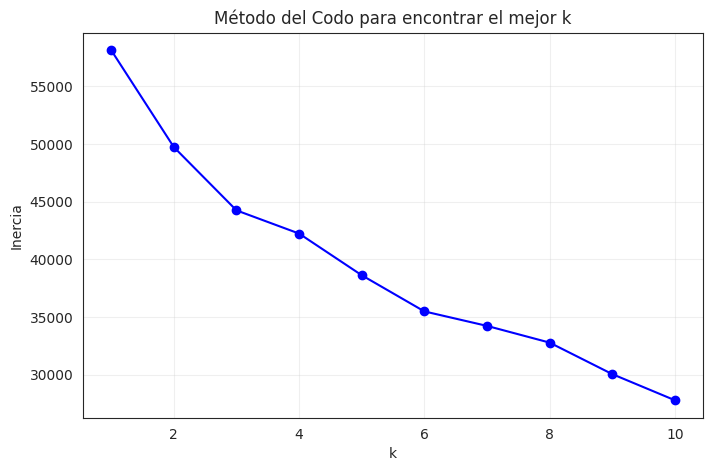

k=1: 58139
k=2: 49737
k=3: 44248
k=4: 42236
k=5: 38623
k=6: 35485
k=7: 34228
k=8: 32778
k=9: 30046
k=10: 27780


In [ ]:
# Calcular inercias para diferentes k
from sklearn.cluster import KMeans

inercias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=21)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

# Graficar método del codo
plt.figure(figsize=(8,5))
plt.plot(k_range, inercias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inercia')
plt.title('Método del Codo para encontrar el mejor k')
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar valores
for k, inercia in zip(k_range, inercias):
    print(f'k={k}: {inercia:.0f}')

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, whiten=True)
X_pca = pca.fit_transform(X_scaled)

print('Shape original: ', X_scaled.shape)
print('Shape PCA:      ', X_pca.shape)

Shape original:  (32581, 22)
Shape PCA:       (32581, 2)


##**4. K-Means**


Labels únicos:    [0 1 2 3]
Centroides shape: (4, 2)


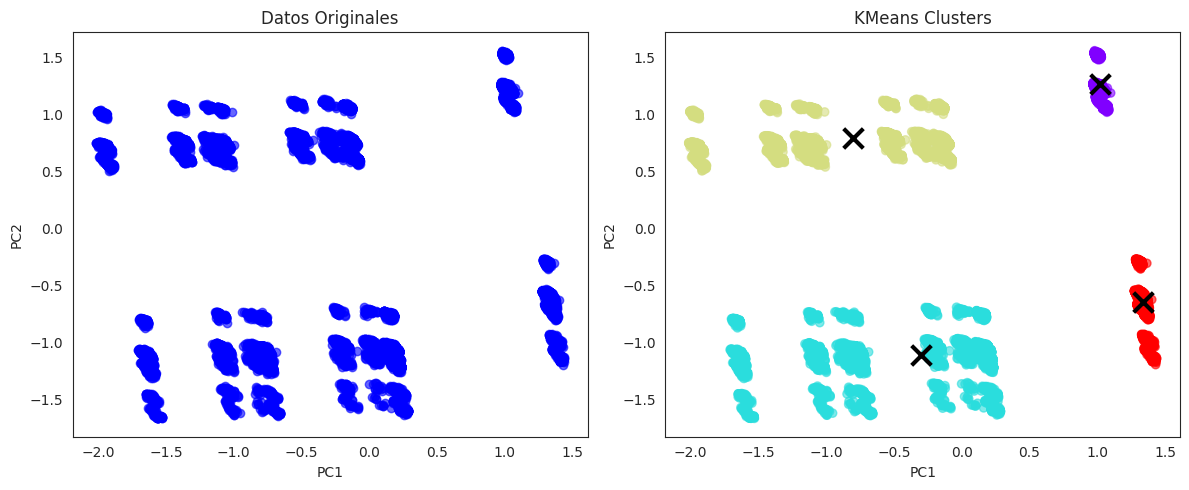

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=21)
kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

print('Labels únicos:   ', np.unique(kmeans.labels_))
print('Centroides shape:', kmeans.cluster_centers_.shape)

# Versión más simple aún (solo 2 subplots)
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.scatter(X_pca[:,0], X_pca[:,1], c="blue", alpha=0.6)
plt.title('Datos Originales')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(122)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans.labels_, cmap='rainbow', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
           color='black', marker='x', s=200, linewidths=3)
plt.title('KMeans Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

##**5. Método de NearestNeighbors**

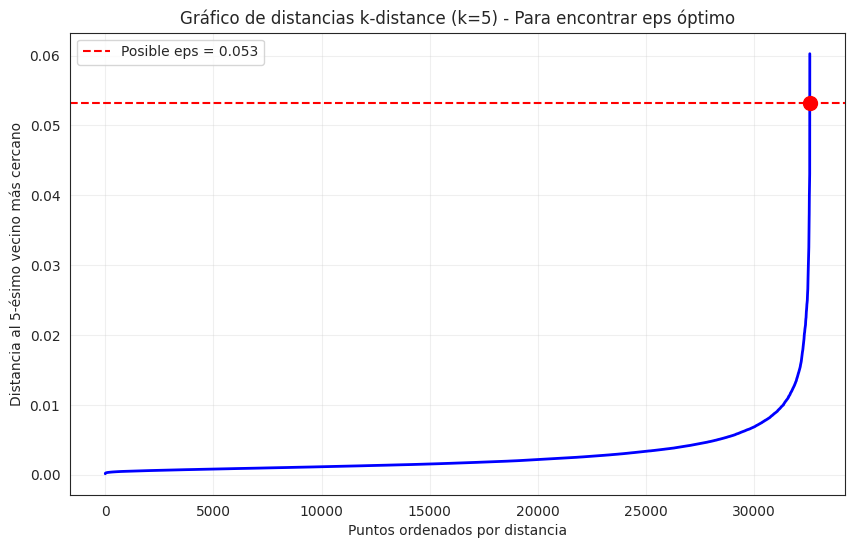

=== MÉTODO DE LA RODILLA (k-distance) ===
min_samples = 5
eps recomendado = 0.0532

=== ESTADÍSTICAS DE DISTANCIAS ===
Media de distancias: 0.0028
Mediana de distancias: 0.0017
Desviación estándar: 0.0035
Percentil 90: 0.0060
Percentil 95: 0.0088
Percentil 99: 0.0178


In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neigh = NearestNeighbors(n_neighbors=min_samples)
neigh.fit(X_pca)
distances, indices = neigh.kneighbors(X_pca)

k_distances = distances[:, -1]

k_distances_sorted = np.sort(k_distances)

plt.figure(figsize=(10, 6))
plt.plot(range(len(k_distances_sorted)), k_distances_sorted, 'b-', linewidth=2)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
plt.title(f'Gráfico de distancias k-distance (k={min_samples}) - Para encontrar eps óptimo')
plt.grid(True, alpha=0.3)

# Encontrar el punto de máxima curvatura (rodilla)
differences = np.diff(k_distances_sorted)
max_diff_index = np.argmax(differences) + 1

# Marcar el punto de la rodilla
plt.axhline(y=k_distances_sorted[max_diff_index], color='red', linestyle='--',
            label=f'Posible eps = {k_distances_sorted[max_diff_index]:.3f}')
plt.scatter(max_diff_index, k_distances_sorted[max_diff_index],
            color='red', s=100, zorder=5)

plt.legend()
plt.show()

# Mostrar el valor recomendado
eps_recomendado = k_distances_sorted[max_diff_index]
print(f"=== MÉTODO DE LA RODILLA (k-distance) ===")
print(f"min_samples = {min_samples}")
print(f"eps recomendado = {eps_recomendado:.4f}")
print(f"")

print("=== ESTADÍSTICAS DE DISTANCIAS ===")
print(f"Media de distancias: {np.mean(k_distances):.4f}")
print(f"Mediana de distancias: {np.median(k_distances):.4f}")
print(f"Desviación estándar: {np.std(k_distances):.4f}")
print(f"Percentil 90: {np.percentile(k_distances, 90):.4f}")
print(f"Percentil 95: {np.percentile(k_distances, 95):.4f}")
print(f"Percentil 99: {np.percentile(k_distances, 99):.4f}")

##**6. DBSCAN**

Labels únicos:   [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31]
Puntos ruido:    2


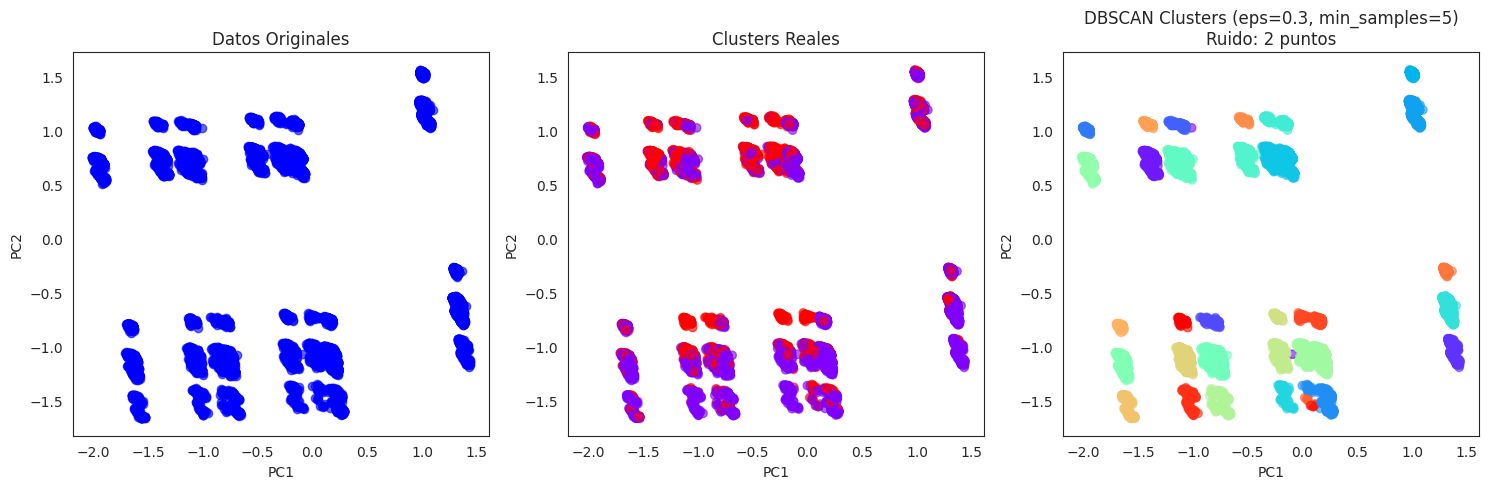

In [ ]:
from sklearn.cluster import DBSCAN

dbs = DBSCAN(eps=0.0532, min_samples=5)
dbs.fit_predict(X_pca)

print('Labels únicos:  ', np.unique(dbs.labels_))
print('Puntos ruido:   ', (dbs.labels_ == -1).sum())

# Gráfico simple de DBSCAN (similar a KMeans)
plt.figure(figsize=(15,5))

# Subplot 1: Datos originales
plt.subplot(131)
plt.scatter(X_pca[:,0], X_pca[:,1], c="blue", alpha=0.6)
plt.title('Datos Originales')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Subplot 2: Clusters reales (si tienes y, si no, omite)
plt.subplot(132)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='rainbow', alpha=0.6)
plt.title('Clusters Reales')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Subplot 3: Resultados de DBSCAN
plt.subplot(133)
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbs.labels_, cmap='rainbow', alpha=0.6)
plt.title(f'DBSCAN Clusters (eps=0.3, min_samples=5)\nRuido: {(dbs.labels_ == -1).sum()} puntos')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

##**5. Resultados**

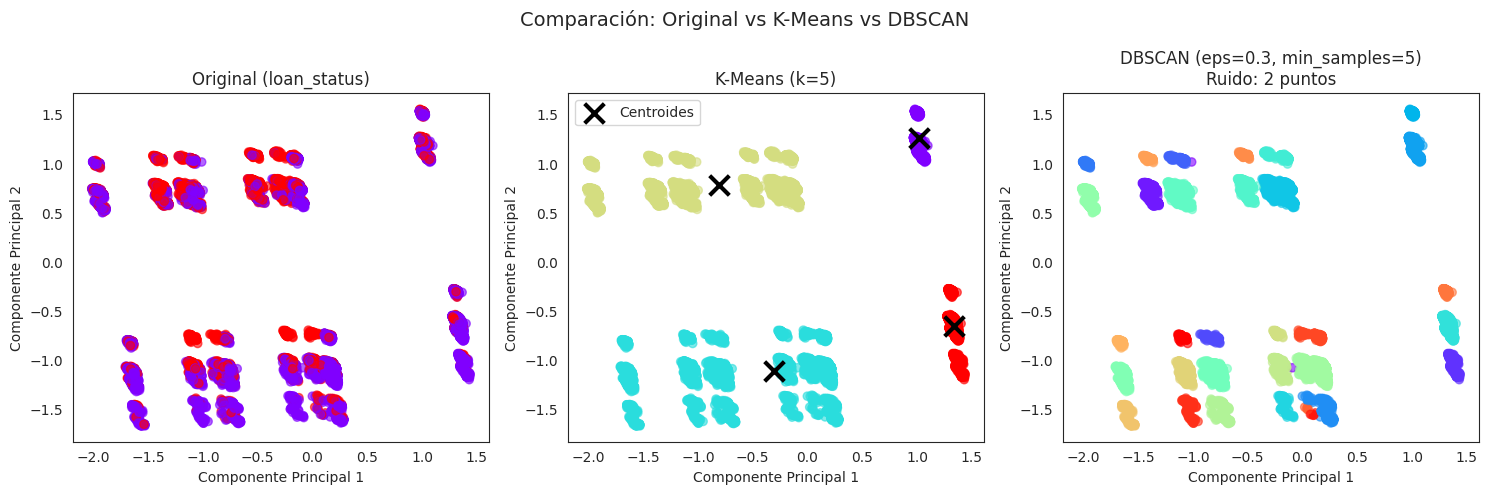

In [ ]:
# Comparación: Original vs K-Means vs DBSCAN
plt.figure(figsize=(15, 5))

# Gráfico 1: Original (loan_status)
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.6, cmap='rainbow')
plt.title('Original (loan_status)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Gráfico 2: K-Means (k=5)
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, alpha=0.6, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           color='black', marker='x', s=200, linewidths=3, label='Centroides')
plt.title(f'K-Means (k=5)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()

# Gráfico 3: DBSCAN (eps=0.3, min_samples=5)
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbs.labels_, alpha=0.6, cmap='rainbow')
plt.title(f'DBSCAN (eps=0.3, min_samples=5)\nRuido: {(dbs.labels_ == -1).sum()} puntos')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.suptitle('Comparación: Original vs K-Means vs DBSCAN', fontsize=14)
plt.tight_layout()
plt.show()

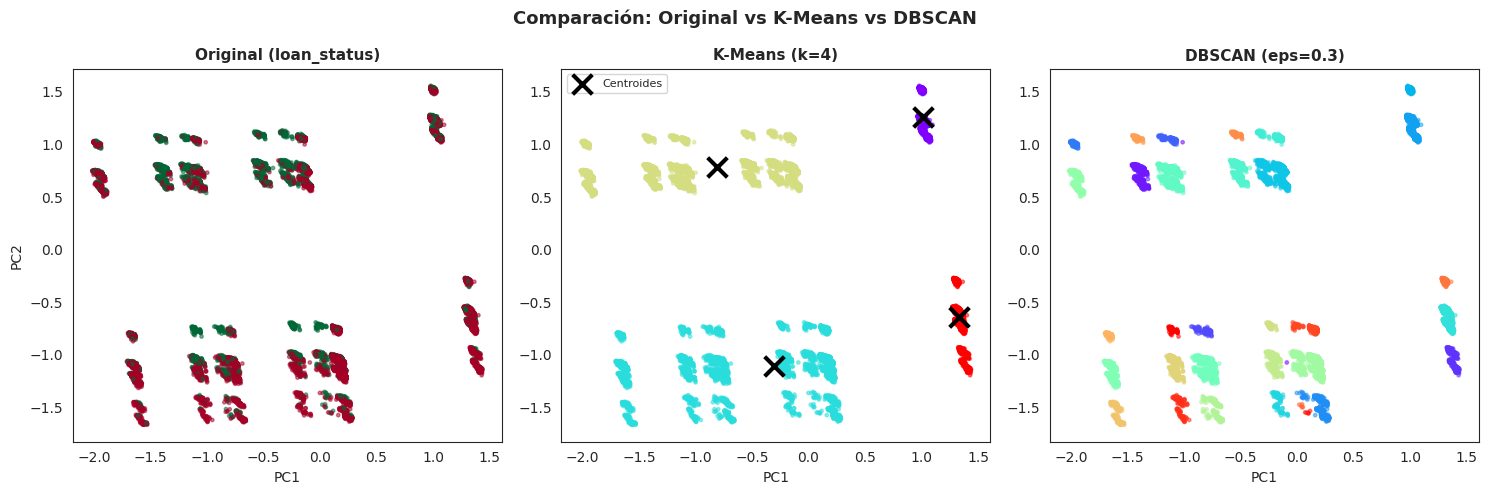

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Original
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=y, cmap='RdYlGn',
                alpha=0.5, s=6)
axes[0].set_title('Original (loan_status)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Gráfico 2: K-Means
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=kmeans.labels_, cmap='rainbow',
                alpha=0.5, s=6)
axes[1].scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                color='black', marker='x',
                s=200, linewidths=3,
                label='Centroides')
axes[1].set_title('K-Means (k=4)',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('PC1')
axes[1].legend(fontsize=8)

# Gráfico 3: DBSCAN
axes[2].scatter(X_pca[:, 0], X_pca[:, 1],
                c=dbs.labels_, cmap='rainbow',
                alpha=0.5, s=6)
axes[2].set_title('DBSCAN (eps=0.3)',
                  fontweight='bold', fontsize=11)
axes[2].set_xlabel('PC1')

plt.suptitle('Comparación: Original vs K-Means vs DBSCAN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('slide17_comparacion.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()